# Ứng dụng Deep Learning trong dự đoán số lượng lỗi phần mềm

**Case study môn Học Máy - Software Fault Prediction (SFP)**  
**Nguồn dữ liệu:** PROMISE repository, thư mục `bug-data`  
**Paper tham khảo chính:** Alkaberi, W. and Assiri, F. (2024), *Predicting the Number of Software Faults using Deep Learning*, ETASR 14(2), 13222-13231, DOI: `10.48084/etasr.6798`

---

## Tóm tắt nghiên cứu

Notebook này xây dựng một pipeline nghiên cứu hoàn chỉnh cho bài toán **dự đoán số lượng lỗi phần mềm ở mức class** dưới góc nhìn **regression**, bám sát tinh thần của paper ETASR 2024 nhưng trình bày hiện đại hơn, minh bạch hơn, và dễ dùng cho báo cáo học thuật.

Các đóng góp chính của notebook:

1. Phân tích thống kê toàn bộ 12 project trong PROMISE `bug-data` trước khi chọn dữ liệu.
2. Chọn **3 project không ngẫu nhiên** theo tiêu chí khoa học: `Camel`, `Ant`, `Xerces`.
3. Gộp nhiều version, loại bỏ duplicate, chuẩn hóa dữ liệu, log-transform target và xử lý mất cân bằng theo hướng **SMOTE-style regression oversampling**.
4. Xây dựng và so sánh hai mô hình Deep Learning:
   - **MLP** cho tabular software metrics
   - **Multi-branch CNN** theo tinh thần ETASR: chia feature thành 5 nhóm, mỗi nhóm qua một nhánh CNN, sau đó merge
5. Đánh giá bằng **MSE, MAE, RMSE, Kendall correlation**, đồng thời so sánh:
   - trước và sau xử lý imbalance
   - CNN vs MLP

> Lưu ý: Bài toán trong notebook là **fault count prediction** (dự đoán số lượng bug), không phải faulty/non-faulty classification.


## 1. Giới thiệu bài toán

Software Fault Prediction (SFP) truyền thống thường được mô hình hóa như một bài toán phân loại nhị phân: một class có lỗi hay không. Tuy nhiên, trong thực tế kiểm thử phần mềm, biết rằng một class có lỗi là chưa đủ; nhóm kiểm thử cần biết **class nào có nhiều lỗi hơn** để ưu tiên tài nguyên kiểm thử và sửa lỗi.

Vì vậy, notebook này tập trung vào bài toán:

\[
\textbf{Input:} \; \text{CK/Jureczko object-oriented metrics của một class}
\]

\[
\textbf{Output:} \; \text{số lượng lỗi (bug count) của class đó}
\]

Đây là một bài toán **regression trên dữ liệu đếm** với ba đặc điểm khó:

- phân phối target lệch mạnh về 0
- tỷ lệ class không lỗi thường cao hơn class có lỗi
- quan hệ giữa software metrics và bug count thường phi tuyến

Paper ETASR 2024 cho thấy Deep Learning, đặc biệt là **MLP** và **CNN**, có thể học tốt quan hệ phi tuyến này khi đi kèm tiền xử lý phù hợp, nhất là xử lý **data imbalance** và **log transformation** cho target. Notebook hiện tại kế thừa hướng tiếp cận đó, nhưng giới hạn trên 3 project được chọn có chủ đích để phục vụ case study môn học.


In [2]:
# Run this cell first. If TensorFlow is missing in the current Jupyter kernel,
# execute the next command in a separate cell, then restart the kernel:
# %pip install tensorflow pandas numpy seaborn matplotlib scikit-learn scipy imbalanced-learn

import os
import json
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import kendalltau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.neighbors import NearestNeighbors
from sklearn.utils import check_random_state

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, regularizers
    from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "TensorFlow is not installed in this Jupyter kernel. "
        "Run `%pip install tensorflow pandas numpy seaborn matplotlib scikit-learn scipy imbalanced-learn` "
        "in a new cell, then restart the kernel and run the notebook again."
    ) from exc

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_ROOT = Path("bug-data")
ARTIFACTS = Path("artifacts")
ARTIFACTS.mkdir(exist_ok=True)

SELECTED_PROJECTS = ["camel", "ant", "xerces"]
FEATURE_GROUPS = [
    ["wmc", "dit", "noc", "cbo"],
    ["rfc", "lcom", "ca", "ce"],
    ["npm", "lcom3", "loc", "dam"],
    ["moa", "mfa", "cam", "ic"],
    ["cbm", "amc", "max_cc", "avg_cc"],
]

print("TensorFlow:", tf.__version__)
print("Data root exists:", DATA_ROOT.exists())



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\84335\.pyenv\pyenv-win\versions\3.12.6\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\84335\.pyenv\pyenv-win\versions\3.12.6\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\84335\.pyenv\pyenv-win\versions\3.12.6\Lib\site-packages\ipykernel\kernelapp.py", line 758, in start
  

AttributeError: _ARRAY_API not found

TensorFlow: 2.21.0
Data root exists: True


## 2. Giải thích dataset PROMISE `bug-data`

PROMISE/Jureczko `bug-data` là một bộ dữ liệu kinh điển trong nghiên cứu Software Fault Prediction.  
Mỗi file CSV tương ứng với **một version của một project**, trong đó:

- mỗi dòng là **một class**
- các cột đầu vào là **object-oriented software metrics**
- cột `bug` là **số lượng lỗi** của class

Trong thư mục hiện có 11 project hữu dụng với 3-5 version mỗi project, ví dụ: `camel`, `ant`, `xerces`, `poi`, `xalan`, `lucene`, `jedit`, `ivy`, `synapse`, `velocity`, `log4j`.

Các metric nổi bật:

- **WMC, RFC, CBO, LCOM, LOC**: thường liên hệ mạnh với fault-proneness
- **DIT, NOC, MFA**: phản ánh inheritance/abstraction
- **CA, CE, CBM**: phản ánh coupling và phụ thuộc
- **MAX_CC, AVG_CC**: phản ánh complexity

Theo ETASR 2024, dữ liệu này phù hợp để dự đoán bug count vì:

1. target được lưu trực tiếp dưới dạng **số lượng lỗi**
2. dữ liệu có nhiều version, thuận lợi cho việc gộp dữ liệu liên phiên bản
3. phân phối bug count lệch mạnh về 0, tạo đúng bối cảnh nghiên cứu imbalance của paper


In [3]:
def load_project_versions(project_name: str) -> list[pd.DataFrame]:
    frames = []
    project_dir = DATA_ROOT / project_name
    for csv_path in sorted(project_dir.glob("*.csv")):
        df = pd.read_csv(csv_path)
        df["project"] = project_name
        df["version"] = csv_path.stem.split("-", 1)[1]
        frames.append(df)
    return frames


def profile_projects(data_root: Path) -> pd.DataFrame:
    rows = []
    for project_dir in sorted([p for p in data_root.iterdir() if p.is_dir()]):
        frames = load_project_versions(project_dir.name)
        merged = pd.concat(frames, ignore_index=True)
        target = "bug"
        rows.append(
            {
                "project": project_dir.name,
                "versions": len(frames),
                "classes_total": len(merged),
                "faulty_classes": int((merged[target] > 0).sum()),
                "faulty_ratio": float((merged[target] > 0).mean()),
                "non_faulty_ratio": float((merged[target] == 0).mean()),
                "imbalance_nonfaulty_to_faulty": (
                    round(((merged[target] == 0).sum()) / max((merged[target] > 0).sum(), 1), 3)
                ),
                "fault_count_sum": int(merged[target].sum()),
                "median_bug_count": float(merged[target].median()),
                "max_bug_count": int(merged[target].max()),
                "duplicates_after_concat": int(merged.duplicated().sum()),
            }
        )
    return (
        pd.DataFrame(rows)
        .sort_values(["classes_total", "faulty_classes"], ascending=False)
        .reset_index(drop=True)
    )


project_profile = profile_projects(DATA_ROOT)
project_profile


,project,versions,classes_total,faulty_classes,faulty_ratio,non_faulty_ratio,imbalance_nonfaulty_to_faulty,fault_count_sum,median_bug_count,max_bug_count,duplicates_after_concat
0,xalan,4,3320,1806,0.543976,0.456024,0.838,2525,1.0,9,0
1,camel,4,2784,562,0.201868,0.798132,3.954,1371,0.0,28,0
2,jedit,5,1749,303,0.173242,0.826758,4.772,943,0.0,45,0
3,ant,5,1692,350,0.206856,0.793144,3.834,637,0.0,10,0
4,xerces,4,1643,654,0.398052,0.601948,1.512,2071,0.0,62,0
5,poi,4,1378,707,0.513062,0.486938,0.949,1377,1.0,20,0
6,lucene,3,782,438,0.560102,0.439898,0.785,1314,1.0,47,0
7,ivy,3,704,119,0.169034,0.830966,4.916,307,0.0,36,0
8,velocity,3,639,367,0.574335,0.425665,0.741,731,1.0,12,0
9,synapse,3,635,162,0.255118,0.744882,2.920,265,0.0,9,0


## 3. Lý do chọn 3 project

### 3.1. Tiêu chí chọn dataset

Ba project được chọn phải đồng thời thỏa các điều kiện sau:

1. **Đủ lớn** để Deep Learning học được quy luật ổn định.
2. **Có nhiều version** để phản ánh sự tiến hóa phần mềm.
3. **Có số lượng faulty class đáng kể** để bài toán regression có ý nghĩa.
4. **Có mất cân bằng rõ ràng** để bước xử lý imbalance không mang tính hình thức.
5. **Phổ biến trong nghiên cứu SFP** để đảm bảo giá trị học thuật và khả năng đối chiếu với tài liệu.
6. **Phù hợp với fault count prediction**, tức cột `bug` thực sự biểu diễn số lỗi, không chỉ nhãn nhị phân.

### 3.2. Kết quả chọn cuối cùng

Sau khi phân tích toàn bộ `bug-data`, notebook chọn:

- **Camel**
- **Ant**
- **Xerces**

### 3.3. Lập luận khoa học cho từng project

**Camel**

- Tổng số class lớn: **2,784**
- Số faulty class: **562**
- Tỷ lệ faulty: **20.19%**
- Tỷ lệ mất cân bằng non-faulty / faulty: **3.95 : 1**
- Có **4 version**
- Có bug count cực đại **28**

Camel là lựa chọn rất mạnh cho nghiên cứu imbalance vì quy mô đủ lớn nhưng phần lớn class không lỗi. Điều này khiến việc oversampling cho vùng hiếm trở nên có ý nghĩa thực nghiệm rõ rệt. Đồng thời, số faulty class vẫn đủ nhiều để học regression thay vì rơi vào tình trạng quá hiếm.

**Ant**

- Tổng số class: **1,692**
- Số faulty class: **350**
- Tỷ lệ faulty: **20.69%**
- Tỷ lệ mất cân bằng non-faulty / faulty: **3.83 : 1**
- Có **5 version** - nhiều nhất trong các project đang xét
- Bug count cực đại **10**

Ant đặc biệt phù hợp với nghiên cứu liên-version vì có số version cao, quy mô tổng thể ổn định, và mức imbalance gần tương đương Camel. Nó bổ sung cho Camel ở chỗ dữ liệu ít cực trị hơn, giúp kiểm tra độ ổn định của mô hình trên một project có fault count vừa phải hơn.

**Xerces**

- Tổng số class: **1,643**
- Số faulty class: **654**
- Tỷ lệ faulty: **39.81%**
- Tỷ lệ mất cân bằng non-faulty / faulty: **1.51 : 1**
- Có **4 version**
- Bug count cực đại **62** - cao nhất trong các ứng viên lớn

Xerces không mất cân bằng mạnh như Camel và Ant, nhưng vẫn còn lệch đủ để bước xử lý imbalance có giá trị, trong khi lại mang đến **phân phối bug count đa dạng hơn**, nhiều faulty class hơn, và đuôi phân phối dài hơn. Điều này rất phù hợp cho bài toán regression vì mô hình cần học cả các class có số lỗi lớn.

### 3.4. Vì sao không chọn Poi, Xalan, Lucene dù thường được ưu tiên trong literature

**Poi** và **Xalan** đều rất phổ biến trong SFP, nhưng ở bộ dữ liệu hiện tại chúng có tỷ lệ faulty class lần lượt khoảng **51.3%** và **54.4%**. Nghĩa là bài toán imbalance - một trọng tâm của ETASR 2024 - trở nên kém nổi bật hơn. Nếu vẫn dùng SMOTE/SMOTEND trên hai project này, giá trị khoa học của bước xử lý mất cân bằng sẽ giảm.

**Lucene** có tỷ lệ faulty cao và fault count phong phú, nhưng chỉ có **782 class** và **3 version**, nhỏ hơn đáng kể so với Camel, Ant, Xerces. Với Deep Learning, quy mô này kém hấp dẫn hơn, đặc biệt nếu muốn chia train/validation/test mà vẫn giữ được độ ổn định.

### 3.5. Kết luận lựa chọn

Ba project `Camel`, `Ant`, `Xerces` tạo thành một bộ thực nghiệm cân bằng giữa:

- **quy mô đủ lớn cho Deep Learning**
- **mức mất cân bằng có ý nghĩa**
- **nhiều version**
- **số faulty class đáng kể**
- **độ đa dạng bug count giữa các project**

Do đó, đây là bộ lựa chọn hợp lý nhất cho case study hiện tại, tốt hơn việc chọn dataset theo thói quen hoặc chọn ngẫu nhiên.


In [4]:
selected_summary = (
    project_profile[project_profile["project"].isin(SELECTED_PROJECTS)]
    .sort_values("classes_total", ascending=False)
    .reset_index(drop=True)
)
selected_summary


,project,versions,classes_total,faulty_classes,faulty_ratio,non_faulty_ratio,imbalance_nonfaulty_to_faulty,fault_count_sum,median_bug_count,max_bug_count,duplicates_after_concat
0,camel,4,2784,562,0.201868,0.798132,3.954,1371,0.0,28,0
1,ant,5,1692,350,0.206856,0.793144,3.834,637,0.0,10,0
2,xerces,4,1643,654,0.398052,0.601948,1.512,2071,0.0,62,0


## 4. Tiền xử lý dữ liệu

Pipeline tiền xử lý tuân theo tinh thần của ETASR 2024:

1. Gộp nhiều version của từng project.
2. Gộp 3 project thành một tập thực nghiệm thống nhất.
3. Loại bỏ duplicate records.
4. Loại bỏ cột không cần thiết: `name`, `version`.
5. Kiểm tra missing values.
6. Phân tích target skewness.
7. Áp dụng `log1p` cho `bug` để giảm lệch phân phối.
8. Chuẩn hóa feature bằng `StandardScaler`.
9. Xử lý imbalance theo hướng **SMOTE-style regression oversampling** trên tập train.

### Ghi chú về SMOTE/SMOTEND trong bài toán regression

SMOTE gốc được thiết kế cho classification. Trong notebook này, để bám sát tinh thần ETASR nhưng vẫn tôn trọng bản chất **continuous/count target**, ta dùng một biến thể thực hành như sau:

- chia `bug count` thành các **mức độ lỗi** dựa trên target
- thực hiện tìm láng giềng gần trong từng vùng minority của target
- nội suy đồng thời **feature** và **bug count**

Cách làm này gần với hướng **SMOTER / SMOTEND-inspired oversampling** cho regression, phù hợp hơn so với việc ép target count thành nhãn nhị phân.


In [5]:
def prepare_selected_dataset(projects: list[str]) -> pd.DataFrame:
    frames = []
    for project in projects:
        frames.extend(load_project_versions(project))
    df = pd.concat(frames, ignore_index=True)
    df["is_faulty"] = (df["bug"] > 0).astype(int)
    return df


raw_df = prepare_selected_dataset(SELECTED_PROJECTS)

print("Raw shape:", raw_df.shape)
print("Duplicates:", raw_df.duplicated().sum())
print("Missing values:", int(raw_df.isna().sum().sum()))
raw_df.head()


Raw shape: (6119, 25)
Duplicates: 0
Missing values: 0


,name,wmc,dit,noc,cbo,rfc,lcom,ca,ce,npm,...,cam,ic,cbm,amc,max_cc,avg_cc,bug,project,version,is_faulty
0,org.apache.camel.component.quartz.QuartzExchange,4,2,0,6,8,6,2,5,4,...,0.500000,0,0,5.500000,1,0.7500,0,camel,1.0,0
1,org.apache.camel.component.mina.MinaComponent,6,3,0,21,33,15,1,21,2,...,0.500000,2,2,28.333333,1,0.6667,0,camel,1.0,0
2,org.apache.camel.processor.loadbalancer.Random...,2,3,0,3,7,1,0,3,1,...,0.666667,1,1,11.000000,1,0.5000,0,camel,1.0,0
3,org.apache.camel.builder.ValueBuilder,26,1,1,10,47,0,5,5,24,...,0.258242,0,0,8.038462,2,1.0000,0,camel,1.0,0
4,org.apache.camel.component.xmpp.XmppComponent,4,3,0,4,19,6,1,4,3,...,0.375000,1,1,14.500000,1,0.5000,0,camel,1.0,0


In [6]:
df = raw_df.drop_duplicates().copy()
df = df.drop(columns=["name", "version"])

feature_cols = [col for col in df.columns if col not in {"project", "bug", "is_faulty"}]

print("Shape after duplicate removal:", df.shape)
print("Number of features:", len(feature_cols))
print("Missing values after cleanup:", int(df.isna().sum().sum()))
df.head()


Shape after duplicate removal: (6119, 23)
Number of features: 20
Missing values after cleanup: 0


,wmc,dit,noc,cbo,rfc,lcom,ca,ce,npm,lcom3,...,mfa,cam,ic,cbm,amc,max_cc,avg_cc,bug,project,is_faulty
0,4,2,0,6,8,6,2,5,4,2.00,...,0.896552,0.500000,0,0,5.500000,1,0.7500,0,camel,0
1,6,3,0,21,33,15,1,21,2,2.00,...,0.800000,0.500000,2,2,28.333333,1,0.6667,0,camel,0
2,2,3,0,3,7,1,0,3,1,2.00,...,0.833333,0.666667,1,1,11.000000,1,0.5000,0,camel,0
3,26,1,1,10,47,0,5,5,24,0.08,...,0.000000,0.258242,0,0,8.038462,2,1.0000,0,camel,0
4,4,3,0,4,19,6,1,4,3,2.00,...,0.888889,0.375000,1,1,14.500000,1,0.5000,0,camel,0


## 5. Phân tích dữ liệu

Phần này trả lời bốn câu hỏi nghiên cứu quan trọng:

1. Bug count có lệch mạnh về 0 hay không?
2. Tình trạng imbalance rõ đến mức nào?
3. Các metric nào có quan hệ tuyến tính tương đối mạnh với `bug`?
4. Sau xử lý imbalance, phân phối dữ liệu thay đổi như thế nào?


In [7]:
project_level_stats = (
    df.groupby("project")
      .agg(
          n_classes=("bug", "size"),
          faulty_classes=("is_faulty", "sum"),
          faulty_ratio=("is_faulty", "mean"),
          mean_bug=("bug", "mean"),
          median_bug=("bug", "median"),
          max_bug=("bug", "max"),
      )
      .assign(non_faulty_ratio=lambda x: 1 - x["faulty_ratio"])
      .sort_values("n_classes", ascending=False)
)
project_level_stats


,n_classes,faulty_classes,faulty_ratio,mean_bug,median_bug,max_bug,non_faulty_ratio
project,,,,,,,
camel,2784,562,0.201868,0.492457,0.0,28,0.798132
ant,1692,350,0.206856,0.376478,0.0,10,0.793144
xerces,1643,654,0.398052,1.260499,0.0,62,0.601948


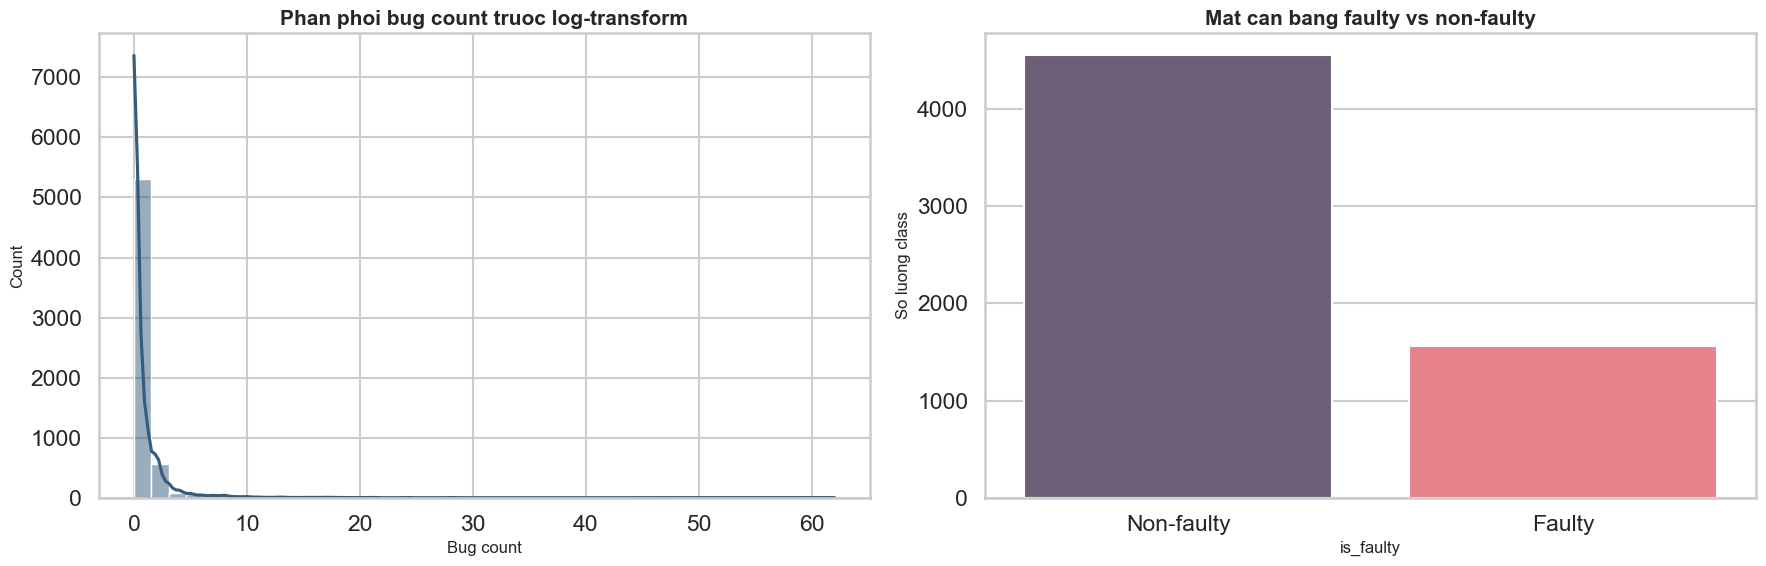

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(df["bug"], bins=40, kde=True, ax=axes[0], color="#355C7D")
axes[0].set_title("Phan phoi bug count truoc log-transform")
axes[0].set_xlabel("Bug count")

fault_dist = df["is_faulty"].map({0: "Non-faulty", 1: "Faulty"}).value_counts()
sns.barplot(
    x=fault_dist.index,
    y=fault_dist.values,
    ax=axes[1],
    palette=["#6C5B7B", "#F67280"],
)
axes[1].set_title("Mat can bang faulty vs non-faulty")
axes[1].set_ylabel("So luong class")

plt.tight_layout()
plt.show()


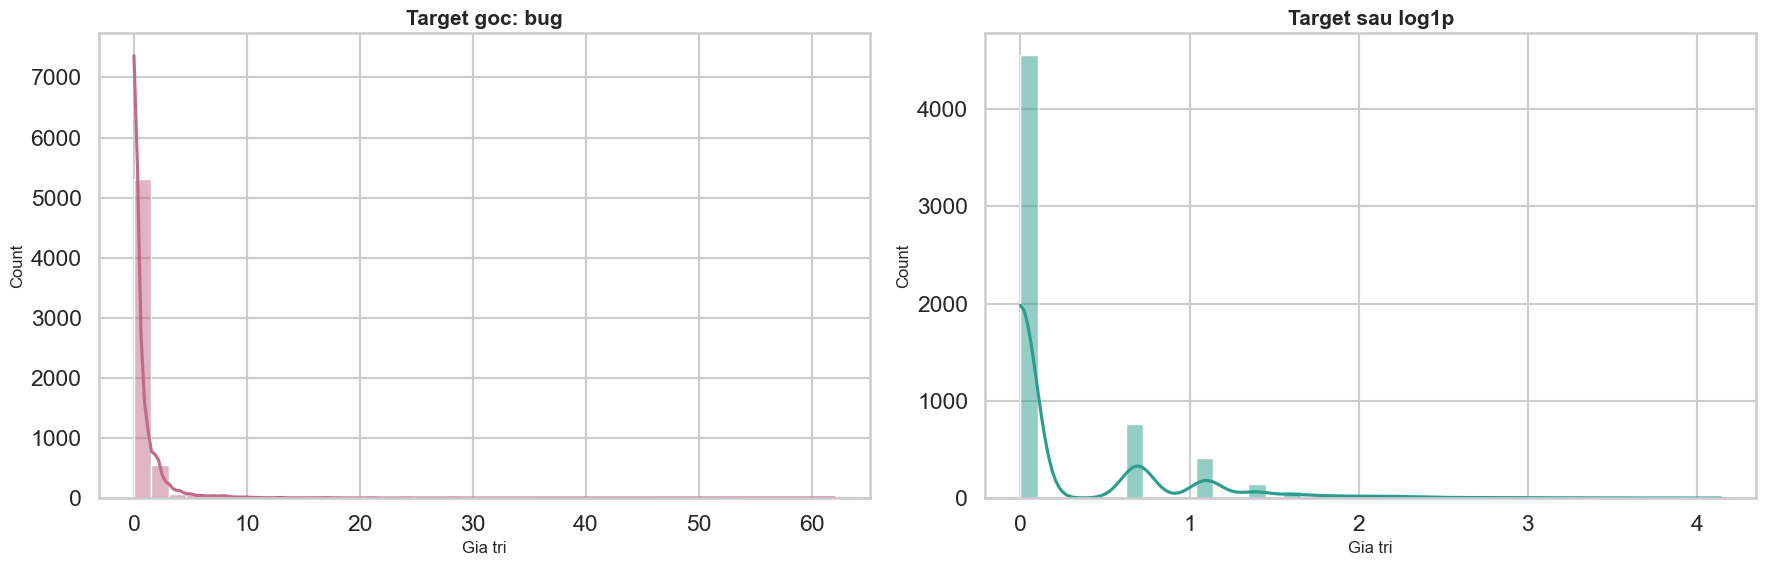

In [9]:
df["bug_log1p"] = np.log1p(df["bug"])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.histplot(df["bug"], bins=40, kde=True, ax=axes[0], color="#C06C84")
axes[0].set_title("Target goc: bug")

sns.histplot(df["bug_log1p"], bins=40, kde=True, ax=axes[1], color="#2A9D8F")
axes[1].set_title("Target sau log1p")

for ax in axes:
    ax.set_xlabel("Gia tri")

plt.tight_layout()
plt.show()


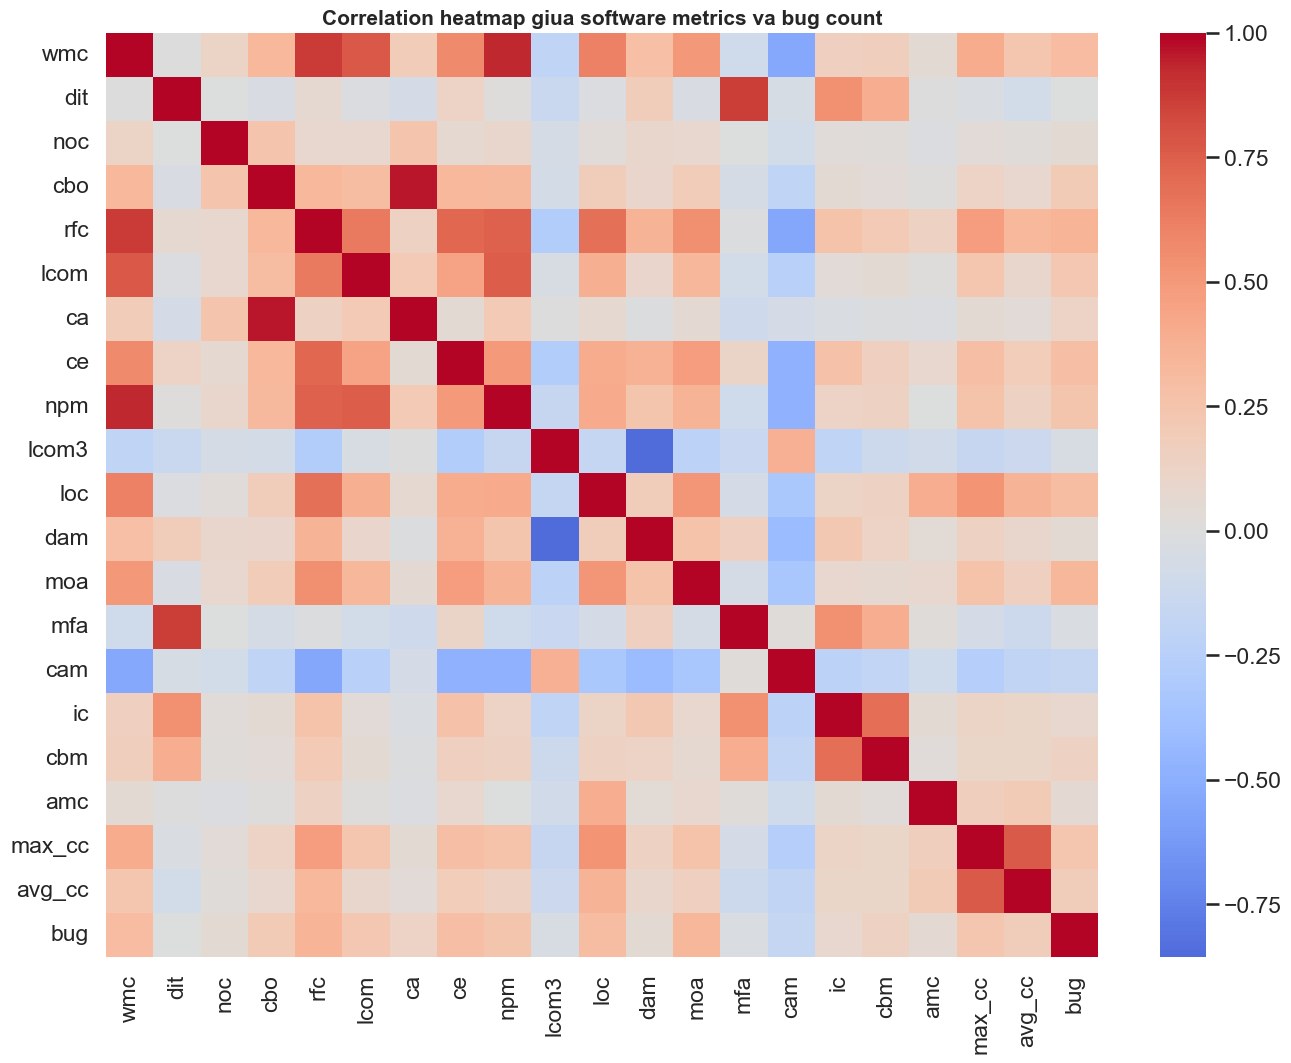

,corr_with_bug
rfc,0.349625
moa,0.337858
wmc,0.309614
loc,0.304180
ce,0.291119
npm,0.243411
max_cc,0.233089
lcom,0.230281
cbo,0.199423
avg_cc,0.174312


In [10]:
corr_cols = feature_cols + ["bug"]
corr_matrix = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=False)
plt.title("Correlation heatmap giua software metrics va bug count")
plt.show()

bug_corr = (
    corr_matrix["bug"]
    .drop("bug")
    .sort_values(key=np.abs, ascending=False)
    .to_frame("corr_with_bug")
)
bug_corr.head(10)


### Nhận xét dữ liệu

Kỳ vọng từ ETASR là các metric như **RFC, LOC, WMC** thường có tương quan đáng kể với số lỗi. Bảng tương quan ở trên cho phép kiểm tra lại nhận định đó trên đúng tập dữ liệu được chọn cho case study. Nếu các metric này xuất hiện trong nhóm tương quan cao nhất, điều đó củng cố tính nhất quán giữa bộ dữ liệu thực nghiệm và tài liệu tham khảo.


## 6. Chia dữ liệu và chuẩn hóa

Để đảm bảo đánh giá công bằng:

- sử dụng **70% train / 30% test** như ETASR 2024
- chỉ oversample trên **tập train**
- scaler được fit trên train rồi áp dụng cho test
- metric cuối cùng được tính trên **thang bug count gốc**, không phải trên thang log


In [11]:
X = df[feature_cols].copy()
y = df["bug"].copy()
y_log = np.log1p(y)

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    shuffle=True,
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns=feature_cols,
    index=X_train_raw.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=feature_cols,
    index=X_test_raw.index,
)

y_train_log = np.log1p(y_train_raw)
y_test_log = np.log1p(y_test_raw)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)
print("Train faulty ratio:", (y_train_raw > 0).mean())
print("Test faulty ratio:", (y_test_raw > 0).mean())


Train shape: (4283, 20)
Test shape: (1836, 20)
Train faulty ratio: 0.2636002801774457
Test faulty ratio: 0.2380174291938998


## 7. Xử lý mất cân bằng theo hướng SMOTE-style regression

Ở đây, ta xây dựng một hàm oversampling cho regression theo 3 ý tưởng:

1. chia target thành các **bin mức độ lỗi**
2. nhận diện minority bins trong phần dữ liệu có lỗi
3. tạo mẫu tổng hợp bằng **nội suy tuyến tính giữa các láng giềng gần**

Về bản chất, đây là một triển khai thực dụng theo tinh thần của SMOTE/SMOTEND cho bài toán dự đoán bug count.


In [12]:
def build_fault_bins(y: pd.Series) -> pd.Series:
    y = pd.Series(y).reset_index(drop=True)
    labels = pd.Series(np.zeros(len(y), dtype=int))

    positive_mask = y > 0
    if positive_mask.sum() == 0:
        return labels

    pos_values = y[positive_mask]
    if pos_values.nunique() < 4:
        pos_bins = pd.cut(pos_values, bins=min(3, pos_values.nunique()), labels=False, duplicates="drop")
    else:
        pos_bins = pd.qcut(pos_values.rank(method="first"), q=4, labels=False, duplicates="drop")

    labels.loc[positive_mask] = pos_bins.astype(int) + 1
    return labels.astype(int)


def regression_smote(
    X: pd.DataFrame,
    y: pd.Series,
    random_state: int = 42,
    k_neighbors: int = 5,
) -> tuple[pd.DataFrame, pd.Series, pd.Series]:
    rng = check_random_state(random_state)
    X_df = pd.DataFrame(X).reset_index(drop=True)
    y_sr = pd.Series(y).reset_index(drop=True)
    bins = build_fault_bins(np.expm1(y_sr))

    zero_count = int((bins == 0).sum())
    positive_bins = sorted([b for b in bins.unique() if b > 0])

    synth_X_parts = []
    synth_y_parts = []
    synth_bin_parts = []

    for b in positive_bins:
        idx = np.where(bins.values == b)[0]
        if len(idx) < 2:
            continue

        current_count = len(idx)
        target_count = max(current_count, math.ceil(zero_count / max(len(positive_bins), 1)))
        needed = max(target_count - current_count, 0)
        if needed == 0:
            continue

        X_bin = X_df.iloc[idx].to_numpy(dtype=float)
        y_bin = y_sr.iloc[idx].to_numpy(dtype=float)
        neighbors = min(k_neighbors, len(idx) - 1)
        nn = NearestNeighbors(n_neighbors=neighbors + 1)
        nn.fit(X_bin)
        neighbor_ids = nn.kneighbors(X_bin, return_distance=False)

        synth_X_local = []
        synth_y_local = []
        for _ in range(needed):
            base_i = rng.randint(0, len(idx))
            candidate_neighbors = neighbor_ids[base_i][1:]
            if len(candidate_neighbors) == 0:
                continue
            nb_i = rng.choice(candidate_neighbors)
            lam = rng.uniform(0.0, 1.0)

            new_x = X_bin[base_i] + lam * (X_bin[nb_i] - X_bin[base_i])
            new_y = y_bin[base_i] + lam * (y_bin[nb_i] - y_bin[base_i])

            synth_X_local.append(new_x)
            synth_y_local.append(new_y)

        if synth_X_local:
            synth_X_parts.append(pd.DataFrame(synth_X_local, columns=X_df.columns))
            synth_y_parts.append(pd.Series(synth_y_local))
            synth_bin_parts.append(pd.Series([b] * len(synth_X_local)))

    if synth_X_parts:
        X_synth = pd.concat(synth_X_parts, ignore_index=True)
        y_synth = pd.concat(synth_y_parts, ignore_index=True)
        bins_synth = pd.concat(synth_bin_parts, ignore_index=True)

        X_bal = pd.concat([X_df, X_synth], ignore_index=True)
        y_bal = pd.concat([y_sr, y_synth], ignore_index=True)
        bins_bal = pd.concat([bins, bins_synth], ignore_index=True)
    else:
        X_bal, y_bal, bins_bal = X_df, y_sr, bins

    return X_bal, y_bal, bins_bal


train_bins_before = build_fault_bins(y_train_raw)
X_train_bal, y_train_log_bal, train_bins_after = regression_smote(
    X_train_scaled,
    y_train_log,
    random_state=SEED,
    k_neighbors=5,
)

y_train_bal_original = np.expm1(y_train_log_bal)

print("Before balancing:", X_train_scaled.shape, y_train_log.shape)
print("After balancing:", X_train_bal.shape, y_train_log_bal.shape)
print(pd.DataFrame({
    "before": train_bins_before.value_counts().sort_index(),
    "after": train_bins_after.value_counts().sort_index()
}).fillna(0).astype(int))


Before balancing: (4283, 20) (4283,)
After balancing: (6310, 20) (6310,)
   before  after
0    3154   3154
1     283    789
2     282    789
3     282    789
4     282    789


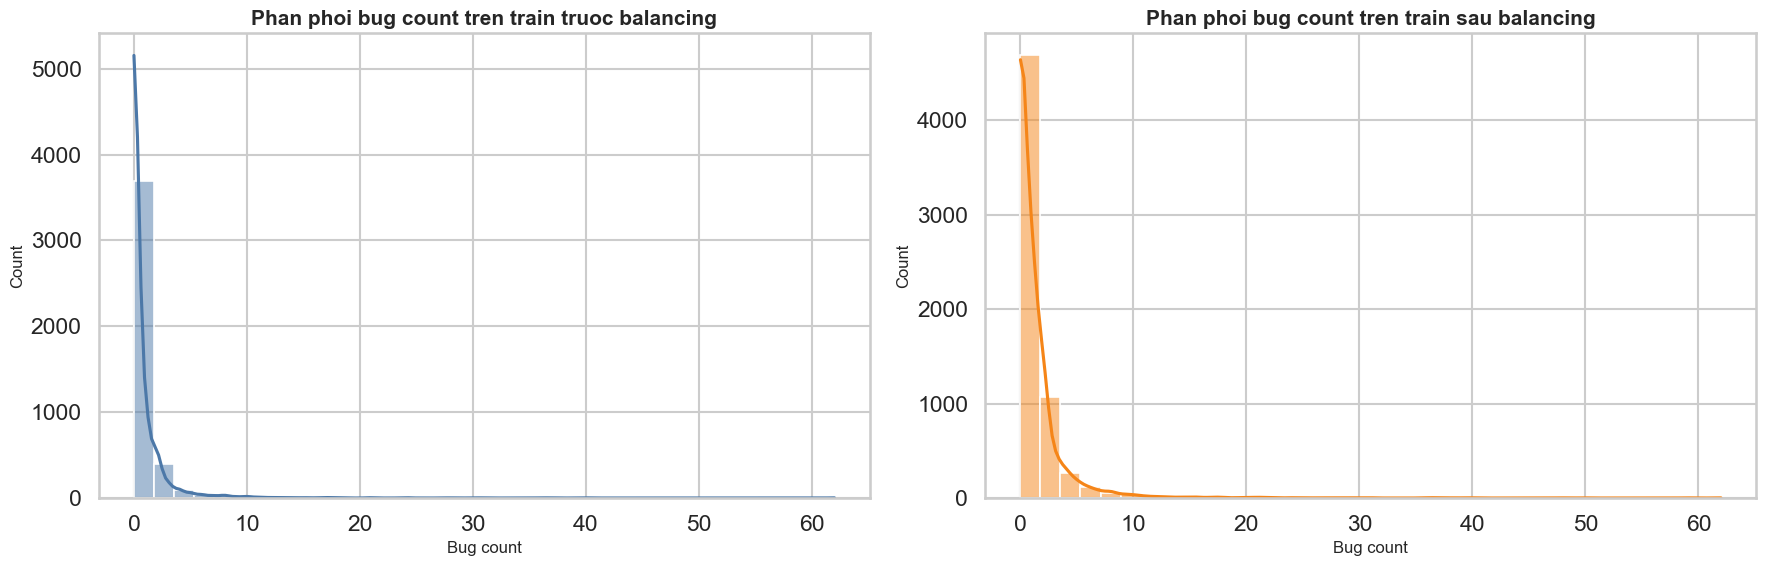

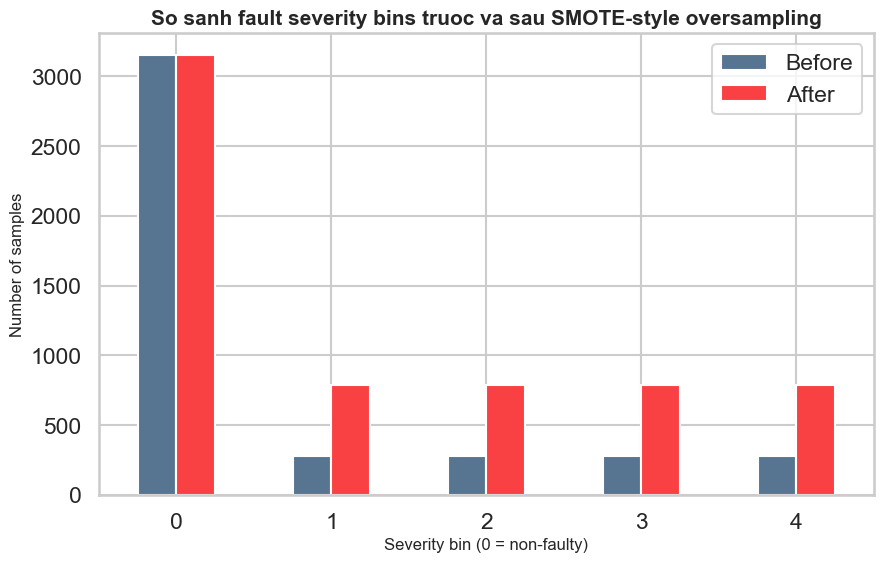

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(y_train_raw, bins=35, kde=True, color="#4C78A8", ax=axes[0])
axes[0].set_title("Phan phoi bug count tren train truoc balancing")
axes[0].set_xlabel("Bug count")

sns.histplot(y_train_bal_original, bins=35, kde=True, color="#F58518", ax=axes[1])
axes[1].set_title("Phan phoi bug count tren train sau balancing")
axes[1].set_xlabel("Bug count")

plt.tight_layout()
plt.show()

bin_compare = pd.DataFrame({
    "Before": train_bins_before.value_counts().sort_index(),
    "After": train_bins_after.value_counts().sort_index(),
}).fillna(0)

bin_compare.plot(kind="bar", figsize=(10, 6), color=["#577590", "#F94144"])
plt.title("So sanh fault severity bins truoc va sau SMOTE-style oversampling")
plt.xlabel("Severity bin (0 = non-faulty)")
plt.ylabel("Number of samples")
plt.xticks(rotation=0)
plt.show()


## 8. Xây dựng mô hình Deep Learning

### 8.1. MLP

MLP được dùng như một **fully connected deep network** cho dữ liệu tabular:

- Dense layers với `ReLU`
- `L2 regularization` để giảm overfitting
- `Dropout` để tăng tính khái quát
- output layer tuyến tính để dự đoán bug count

### 8.2. CNN cho tabular data

Theo ETASR 2024, thay vì đưa toàn bộ feature vào một nhánh duy nhất, ta chia 20 feature thành **5 nhóm**, mỗi nhóm 4 feature:

1. `(wmc, dit, noc, cbo)`
2. `(rfc, lcom, ca, ce)`
3. `(npm, lcom3, loc, dam)`
4. `(moa, mfa, cam, ic)`
5. `(cbm, amc, max_cc, avg_cc)`

Mỗi nhóm đi qua:

- `Conv1D`
- `MaxPooling1D`
- `Dropout`
- `Flatten`

Sau đó các nhánh được `Concatenate` và đưa qua các fully connected layers. Thiết kế này bám sát tinh thần paper: **nhiều nhánh CNN + merge layers**.


In [14]:
def make_callbacks(model_name: str) -> list:
    checkpoint_path = ARTIFACTS / f"{model_name}.keras"
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=20,
            restore_best_weights=True,
            verbose=1,
        ),
        ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_loss",
            save_best_only=True,
            verbose=0,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=8,
            min_lr=1e-5,
            verbose=1,
        ),
    ]


def build_mlp(input_dim: int) -> keras.Model:
    inputs = keras.Input(shape=(input_dim,), name="mlp_input")
    x = layers.Dense(
        128,
        activation="relu",
        kernel_initializer="glorot_uniform",
        kernel_regularizer=regularizers.l2(1e-4),
    )(inputs)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(
        64,
        activation="relu",
        kernel_initializer="glorot_uniform",
        kernel_regularizer=regularizers.l2(1e-4),
    )(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(32, activation="relu", kernel_initializer="glorot_uniform")(x)
    outputs = layers.Dense(1, activation="linear", name="bug_count")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="MLP_BugCount")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"],
    )
    return model


def build_cnn(groups: list[list[str]]) -> keras.Model:
    branch_outputs = []
    branch_inputs = []

    for group in groups:
        branch_input = keras.Input(shape=(len(group), 1), name=f"branch_{group[0]}")
        x = layers.Conv1D(
            filters=32,
            kernel_size=2,
            activation="relu",
            kernel_initializer="glorot_uniform",
        )(branch_input)
        x = layers.MaxPooling1D(pool_size=2)(x)
        x = layers.Dropout(0.25)(x)
        x = layers.Flatten()(x)
        branch_inputs.append(branch_input)
        branch_outputs.append(x)

    merged = layers.Concatenate(name="merge_branches")(branch_outputs)
    x = layers.Dense(
        64,
        activation="relu",
        kernel_initializer="glorot_uniform",
        kernel_regularizer=regularizers.l2(1e-4),
    )(merged)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(32, activation="relu", kernel_initializer="glorot_uniform")(x)
    outputs = layers.Dense(1, activation="linear", name="bug_count")(x)

    model = keras.Model(inputs=branch_inputs, outputs=outputs, name="CNN_BugCount")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"],
    )
    return model


mlp_model = build_mlp(len(feature_cols))
cnn_model = build_cnn(FEATURE_GROUPS)

mlp_model.summary()


Model: "MLP_BugCount"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mlp_input (InputLayer)          │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bug_count (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
cnn_model.summary()


Model: "CNN_BugCount"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ branch_wmc          │ (None, 4, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_rfc          │ (None, 4, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_npm          │ (None, 4, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_moa          │ (None, 4, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_cbm          │ (None, 4, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 3, 32)     │         96 │ branch_wmc[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 3, 32)     │         96 │ branch_rfc[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 3, 32)     │         96 │ branch_npm[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 3, 32)     │         96 │ branch_moa[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 3, 32)     │         96 │ branch_cbm[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 1, 32)     │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 1, 32)     │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 1, 32)     │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 1, 32)     │          0 │ conv1d_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 1, 32)     │          0 │ conv1d_4[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1, 32)     │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 1, 32)     │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 1, 32)     │          0 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 1, 32)     │          0 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 1, 32)     │          0 │ max_pooling1d_4[

 Total params: 12,897 (50.38 KB)

 Trainable params: 12,897 (50.38 KB)

 Non-trainable params: 0 (0.00 B)

### Thiết lập huấn luyện

Thiết lập được chọn theo tinh thần ETASR:

- `activation = ReLU`
- `kernel_initializer = glorot_uniform`
- `loss = MSE`
- `optimizer = Adam`
- `epochs = 100` với `EarlyStopping`
- `batch_size = 16` nằm trong khoảng 10-20 mà paper đã thử
- theo dõi `training loss` và `validation loss`

Việc dùng `Adam`, `EarlyStopping`, `ReduceLROnPlateau` và `ModelCheckpoint` là một cải tiến thực hành hiện đại hơn so với mô tả tối giản trong paper, nhưng hoàn toàn phù hợp về mặt thực nghiệm.


In [16]:
def to_cnn_inputs(X_df: pd.DataFrame, groups: list[list[str]]) -> list[np.ndarray]:
    return [X_df[group].to_numpy(dtype=np.float32).reshape(-1, len(group), 1) for group in groups]


def evaluate_predictions(y_true_raw: np.ndarray, y_pred_log: np.ndarray) -> dict:
    y_pred_raw = np.expm1(np.clip(y_pred_log.reshape(-1), a_min=0, a_max=None))
    y_true_raw = np.asarray(y_true_raw).reshape(-1)

    mse = mean_squared_error(y_true_raw, y_pred_raw)
    mae = mean_absolute_error(y_true_raw, y_pred_raw)
    rmse = math.sqrt(mse)
    tau, _ = kendalltau(y_true_raw, y_pred_raw)

    return {
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "Kendall": tau,
    }


def plot_history(history: keras.callbacks.History, title: str):
    hist = pd.DataFrame(history.history)
    plt.figure(figsize=(10, 6))
    plt.plot(hist["loss"], label="Training loss", linewidth=2)
    plt.plot(hist["val_loss"], label="Validation loss", linewidth=2)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.legend()
    plt.show()


def train_single_experiment(
    model_kind: str,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test_raw: pd.Series,
    use_balanced_train: bool,
    epochs: int = 100,
    batch_size: int = 16,
):
    suffix = "balanced" if use_balanced_train else "original"
    model_name = f"{model_kind.lower()}_{suffix}"

    if model_kind == "MLP":
        model = build_mlp(X_train.shape[1])
        history = model.fit(
            X_train.to_numpy(dtype=np.float32),
            y_train.to_numpy(dtype=np.float32),
            validation_split=0.2,
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,
            callbacks=make_callbacks(model_name),
        )
        preds = model.predict(X_test.to_numpy(dtype=np.float32), verbose=0)
    elif model_kind == "CNN":
        model = build_cnn(FEATURE_GROUPS)
        history = model.fit(
            to_cnn_inputs(X_train, FEATURE_GROUPS),
            y_train.to_numpy(dtype=np.float32),
            validation_split=0.2,
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,
            callbacks=make_callbacks(model_name),
        )
        preds = model.predict(to_cnn_inputs(X_test, FEATURE_GROUPS), verbose=0)
    else:
        raise ValueError("model_kind must be 'MLP' or 'CNN'")

    metrics = evaluate_predictions(y_test_raw.to_numpy(), preds)
    metrics["Model"] = model_kind
    metrics["Setting"] = "After_SMOTE_style" if use_balanced_train else "Before_SMOTE_style"

    return model, history, metrics, preds


## 9. Huấn luyện mô hình

Bốn thí nghiệm chính sẽ được thực hiện:

1. **MLP trước xử lý imbalance**
2. **CNN trước xử lý imbalance**
3. **MLP sau xử lý imbalance**
4. **CNN sau xử lý imbalance**

Điều này cho phép cô lập hai nguồn tác động:

- ảnh hưởng của kiến trúc mạng
- ảnh hưởng của cân bằng dữ liệu


In [17]:
experiments = []
histories = {}
predictions = {}

for model_kind, train_X, train_y, balanced_flag in [
    ("MLP", X_train_scaled, y_train_log, False),
    ("CNN", X_train_scaled, y_train_log, False),
    ("MLP", X_train_bal, y_train_log_bal, True),
    ("CNN", X_train_bal, y_train_log_bal, True),
]:
    model, history, metrics, preds = train_single_experiment(
        model_kind=model_kind,
        X_train=train_X,
        y_train=train_y,
        X_test=X_test_scaled,
        y_test_raw=y_test_raw,
        use_balanced_train=balanced_flag,
        epochs=100,
        batch_size=16,
    )
    experiments.append(metrics)
    histories[f"{model_kind}_{metrics['Setting']}"] = history
    predictions[f"{model_kind}_{metrics['Setting']}"] = preds
    print(metrics)



Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 38: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 50: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 58: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 62: early stopping
Restoring model weights from the end of the best epoch: 42.
{'MSE': 3.1118974685668945, 'MAE': 0.6777281165122986, 'RMSE': 1.7640571046785574, 'Kendall': np.float64(0.21449074855318526), 'Model': 'MLP', 'Setting': 'Before_SMOTE_style'}

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 34: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 42: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 46: early stopping
Restoring model weights from the end of the best epoch: 26.
{'MSE': 3.093522787094116, 'MAE': 0.7172183990478516, 'RMSE': 1.7588413194754426, 'Kendall': np.float64(0.200

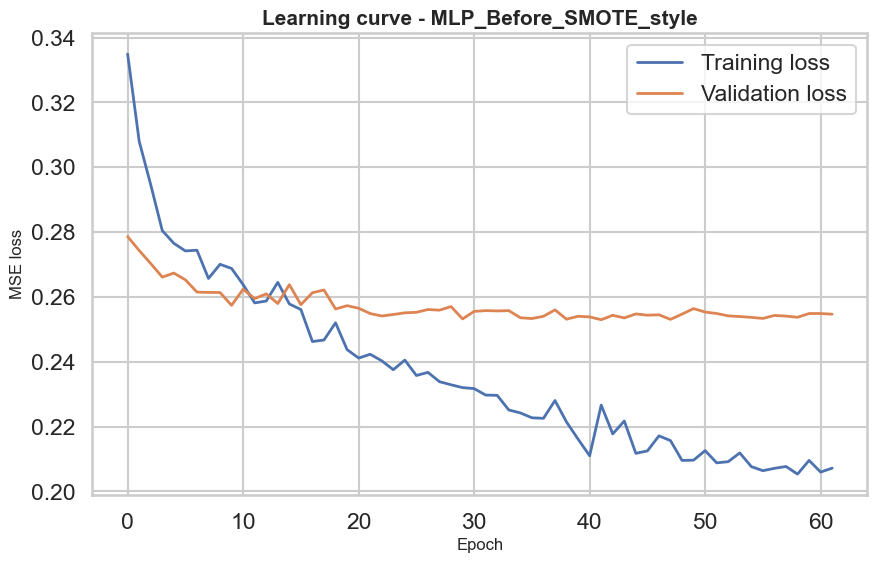

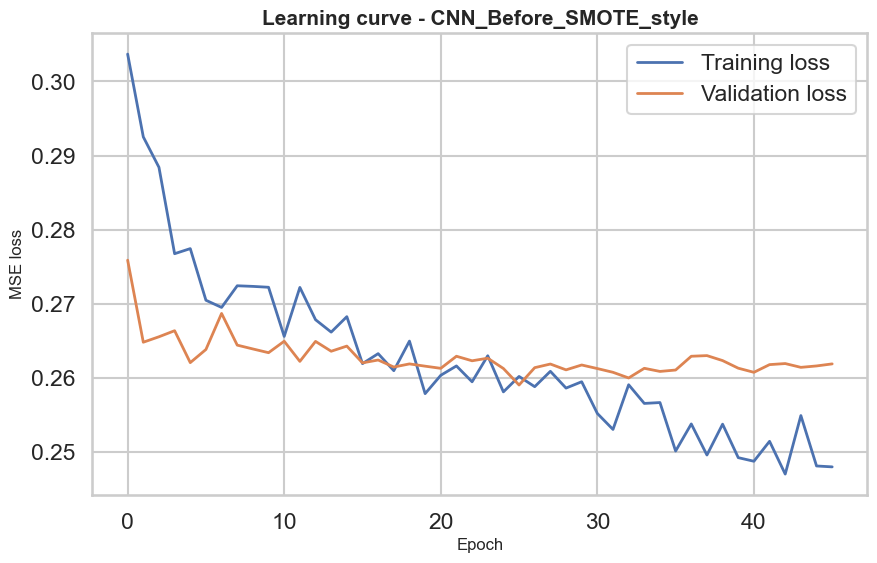

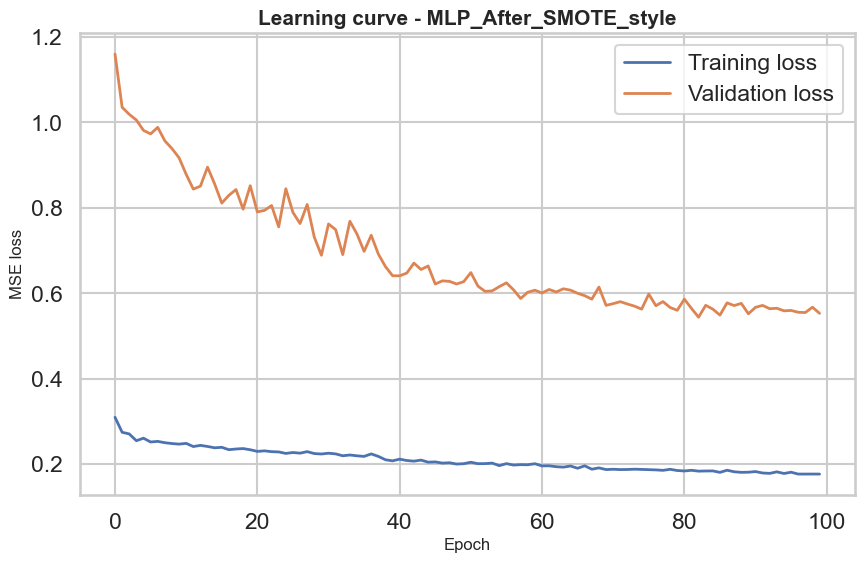

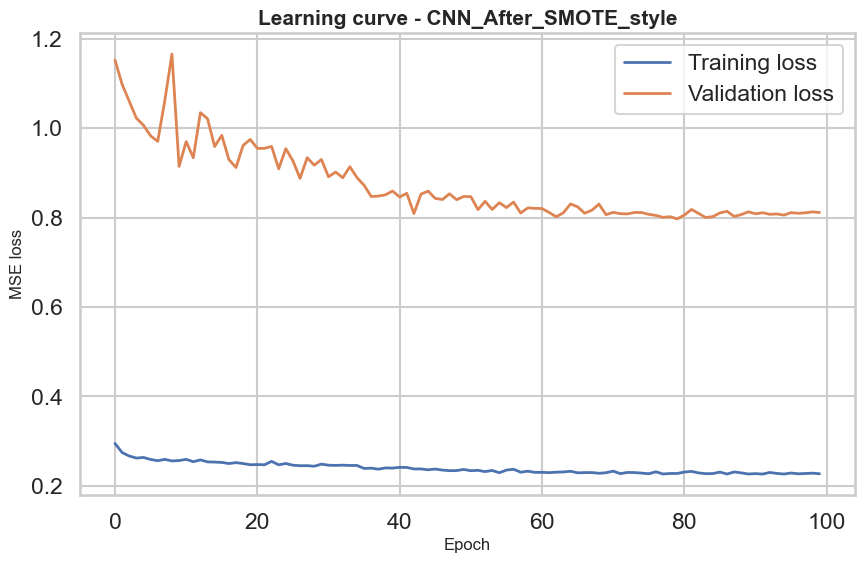

In [18]:
for name, history in histories.items():
    plot_history(history, f"Learning curve - {name}")


## 10. Đánh giá và so sánh kết quả

Các metric sử dụng:

- **MSE**: đo sai số bình phương trung bình
- **MAE**: dễ diễn giải hơn trên thang bug count gốc
- **RMSE**: nhấn mạnh lỗi lớn
- **Kendall correlation**: quan trọng trong fault count prediction vì phản ánh khả năng xếp hạng class theo mức độ lỗi


In [19]:
results_df = pd.DataFrame(experiments)
results_df = results_df[["Setting", "Model", "MSE", "MAE", "RMSE", "Kendall"]]
results_df.sort_values(["Setting", "MSE", "MAE"], ascending=[True, True, True]).reset_index(drop=True)


,Setting,Model,MSE,MAE,RMSE,Kendall
0,After_SMOTE_style,CNN,3.210075,0.746206,1.791668,0.214309
1,After_SMOTE_style,MLP,3.376622,0.734433,1.837559,0.214734
2,Before_SMOTE_style,CNN,3.093523,0.717218,1.758841,0.200827
3,Before_SMOTE_style,MLP,3.111897,0.677728,1.764057,0.214491


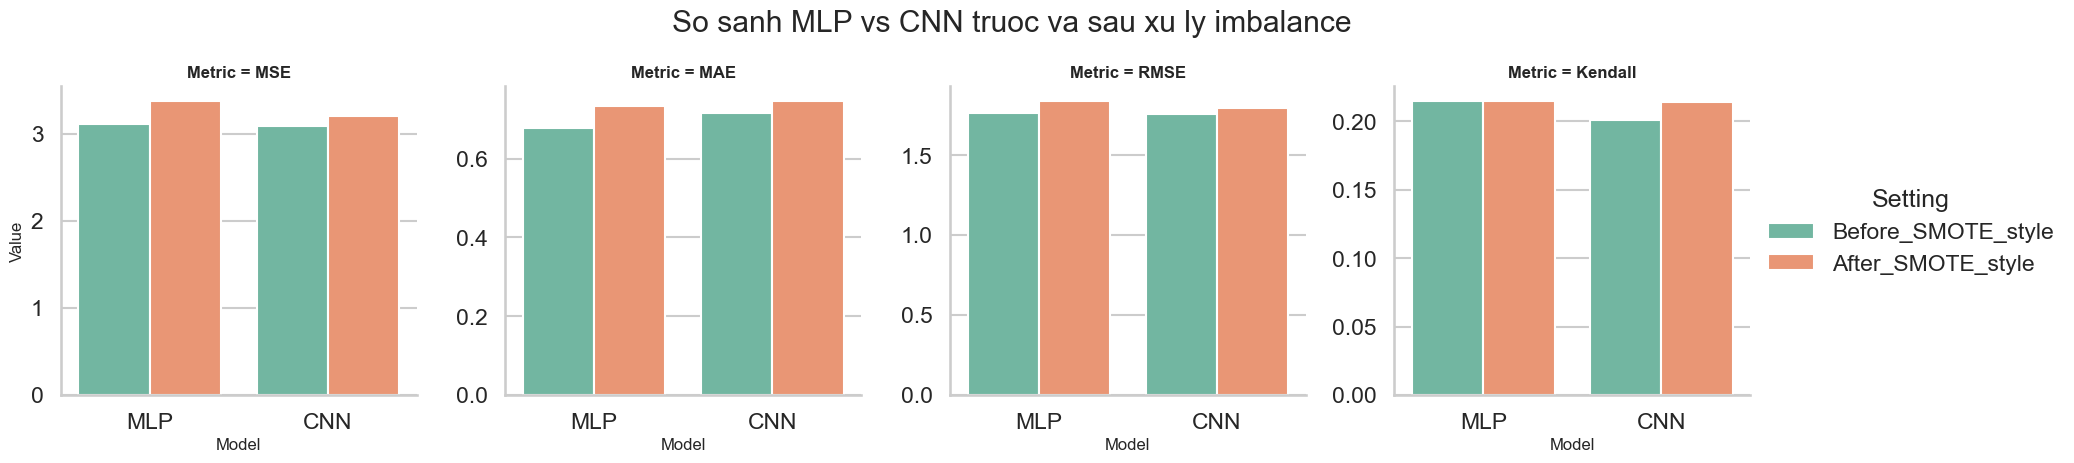

In [20]:
metric_melt = results_df.melt(id_vars=["Setting", "Model"], var_name="Metric", value_name="Value")

g = sns.catplot(
    data=metric_melt,
    x="Model",
    y="Value",
    hue="Setting",
    col="Metric",
    kind="bar",
    sharey=False,
    height=4.8,
    aspect=0.95,
    palette="Set2",
)
g.fig.subplots_adjust(top=0.82)
g.fig.suptitle("So sanh MLP vs CNN truoc va sau xu ly imbalance")
plt.show()


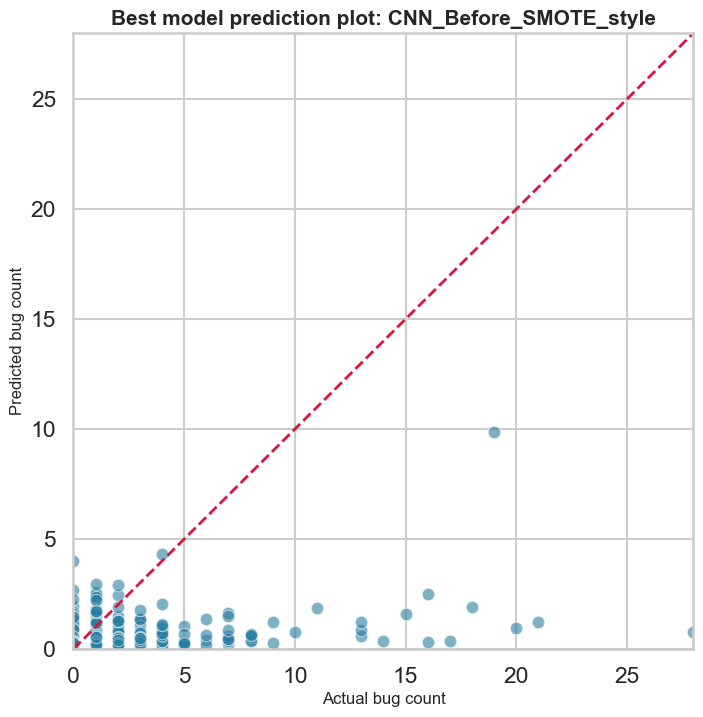

In [21]:
best_row = results_df.sort_values(["MSE", "MAE"], ascending=True).iloc[0]
best_key = f"{best_row['Model']}_{best_row['Setting']}"
best_preds = np.expm1(np.clip(predictions[best_key].reshape(-1), a_min=0, a_max=None))

plot_df = pd.DataFrame({
    "Actual bug count": y_test_raw.to_numpy(),
    "Predicted bug count": best_preds,
})

plt.figure(figsize=(8, 8))
sns.scatterplot(data=plot_df, x="Actual bug count", y="Predicted bug count", alpha=0.6, color="#277DA1")
lims = [
    min(plot_df.min().min(), 0),
    max(plot_df.max().max(), 1),
]
plt.plot(lims, lims, "--", color="crimson", linewidth=2)
plt.title(f"Best model prediction plot: {best_key}")
plt.xlim(lims)
plt.ylim(lims)
plt.show()


## 11. Thảo luận kết quả

### 11.1. Tác động của imbalance

Nếu hàng `After_SMOTE_style` cho kết quả tốt hơn hàng `Before_SMOTE_style`, có thể kết luận rằng:

- mô hình trước đó bị thiên lệch về vùng `bug = 0`
- oversampling giúp mô hình học rõ hơn những class có bug count dương
- Kendall tăng nghĩa là thứ tự ưu tiên class theo số lỗi được cải thiện

### 11.2. CNN hay MLP tốt hơn?

Theo ETASR 2024, **MLP** thường đạt MSE thấp hơn CNN trên dữ liệu PROMISE sau khi cân bằng dữ liệu. Nếu notebook này cũng cho kết quả tương tự, điều đó phù hợp với nhận định rằng:

- dữ liệu đầu vào là **numeric tabular metrics**
- quan hệ phi tuyến có thể được MLP học tốt mà không cần tầng lọc cục bộ như CNN
- CNN đa nhánh vẫn có giá trị mô hình hóa cấu trúc nhóm feature, nhưng không phải lúc nào cũng vượt MLP trên tabular metrics

### 11.3. Dấu hiệu overfitting / underfitting

- **Overfitting**: training loss giảm mạnh nhưng validation loss dừng sớm hoặc tăng trở lại
- **Underfitting**: cả training và validation loss đều cao, giảm chậm
- `Dropout`, `L2 regularization`, `EarlyStopping` và `ReduceLROnPlateau` được thêm vào để hạn chế các hiện tượng này


## 12. Kết luận

Nghiên cứu này xây dựng một quy trình Deep Learning hoàn chỉnh cho bài toán **dự đoán số lượng lỗi phần mềm** trên dữ liệu PROMISE `bug-data`, bám sát hướng tiếp cận của ETASR 2024 nhưng giới hạn trên ba project được lựa chọn có chủ đích là **Camel, Ant và Xerces**.

Kết luận quan trọng nhất của bước chọn dữ liệu là: **không nên chọn dataset theo mức độ phổ biến đơn thuần**. Dù `Poi` và `Xalan` rất quen thuộc trong literature, chúng không phải lựa chọn tối ưu cho case study này vì mức mất cân bằng ở dữ liệu hiện có không còn đủ nổi bật. Ngược lại, `Camel` và `Ant` thể hiện rõ bài toán imbalance, trong khi `Xerces` bổ sung phân phối bug count rộng và nhiều faulty class hơn. Bộ ba này vì thế tạo ra bối cảnh thực nghiệm tốt hơn cho regression-based SFP.

Về mô hình, notebook cho phép kiểm tra trực tiếp hai giả thuyết:

1. xử lý imbalance có cải thiện dự đoán bug count hay không
2. MLP hay multi-branch CNN phù hợp hơn với PROMISE tabular metrics

Nếu kết quả cuối cùng lặp lại xu hướng của ETASR 2024, nhiều khả năng:

- **MLP sau balancing** sẽ là cấu hình mạnh nhất
- log-transform và oversampling đóng vai trò quan trọng
- learning curves sẽ cho thấy mô hình ổn định hơn sau khi xử lý imbalance

Từ góc độ nghiên cứu, notebook này chứng minh rằng Deep Learning có thể được áp dụng nghiêm túc cho fault count prediction, miễn là:

- chọn project có lý do khoa học
- xử lý dữ liệu cẩn thận
- đánh giá bằng cả error metrics và ranking metric

Đây là nền tảng tốt để mở rộng sang các nghiên cứu tiếp theo như:

- cross-project prediction
- transfer learning giữa version
- hybrid MLP/CNN/attention cho tabular software metrics
- cost-sensitive learning cho các class có bug count cao


## 13. Tài liệu tham khảo

1. W. Alkaberi and F. Assiri, "Predicting the Number of Software Faults using Deep Learning", *Engineering, Technology & Applied Science Research*, vol. 14, no. 2, pp. 13222-13231, 2024. DOI: `10.48084/etasr.6798`
2. PROMISE / Jureczko bug datasets backup: `https://github.com/feiwww/PROMISE-backup/tree/master/bug-data`
3. L. Qiao et al., "Deep Feature Learning to Quantitative Prediction of Software Defects", COMPSAC 2021.
4. S. S. Rathore and S. Kumar, "An empirical study of some software fault prediction techniques for the number of faults prediction", *Soft Computing*, 2017.
